In [67]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [68]:
# base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'


In [69]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Cameroon/data'

In [70]:
# NUTS2 = 'Thrace'
# YEAR = '2024'

In [71]:
GID2_NAME = 'Nord'
YEAR = '2023'

In [72]:
# df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding=enc)

In [73]:
df = pd.read_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_{YEAR}_filled.csv', encoding=enc)

In [74]:
df.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-01,2023,1,2023-01-01,8.221831,12.291199,0.229248,-0.148433,-0.308036,0.148433,0.251176,-0.135636,-0.307917,0.135636,0.021703,0.022568,0.008868,0.022568,2023-01-01,8.221831,12.291199,15143.0,NaN,2023-01-01,8.250038,12.250056,2022-12-31,2022-12-31,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-02,2023,1,2023-01-02,8.221831,12.291199,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,2023-01-02,8.221831,12.291199,15261.0,NaN,2023-01-02,8.250038,12.250056,2023-01-01,2023-01-01,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-03,2023,1,2023-01-03,8.221831,12.291199,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,2023-01-03,8.221831,12.291199,15261.0,14538.0,2023-01-03,8.250038,12.250056,2023-01-02,2023-01-02,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-04,2023,1,2023-01-04,8.221831,12.291199,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,2023-01-04,8.221831,12.291199,15261.0,14517.0,2023-01-04,8.250038,12.250056,2023-01-03,2023-01-03,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-05,2023,1,2023-01-05,8.221831,12.291199,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,2023-01-05,8.221831,12.291199,15292.0,14517.0,2023-01-05,8.250038,12.250056,2023-01-04,2023-01-04,0.0


In [75]:
date_columns = [col for col in df.columns if 'dt_placement' in col.lower() or 'date' in col.lower()]
print(f"Date columns: {date_columns}")
for col_name in date_columns:
    df[col_name] = pd.to_datetime(df[col_name])

# df['dt_placement'] = pd.to_datetime(df['dt_placement'])
# df['indices_image_date'] = pd.to_datetime(df['indices_image_date'])
# df['lst_image_date'] = pd.to_datetime(df['lst_image_date'])
# df['indices_image_date.1'] = pd.to_datetime(df['indices_image_date.1'])
# df['dt_placement_minus_1'] = pd.to_datetime(df['dt_placement_minus_1'])
# df['dt_placement_minus_1_avail'] = pd.to_datetime(df['dt_placement_minus_1_avail'])

Date columns: ['dt_placement', 'indices_image_date', 'lst_image_date', 'indices_image_date.1', 'dt_placement_minus_1', 'dt_placement_minus_1_avail']


Text(0.5, 1.0, 'Year: 2023')

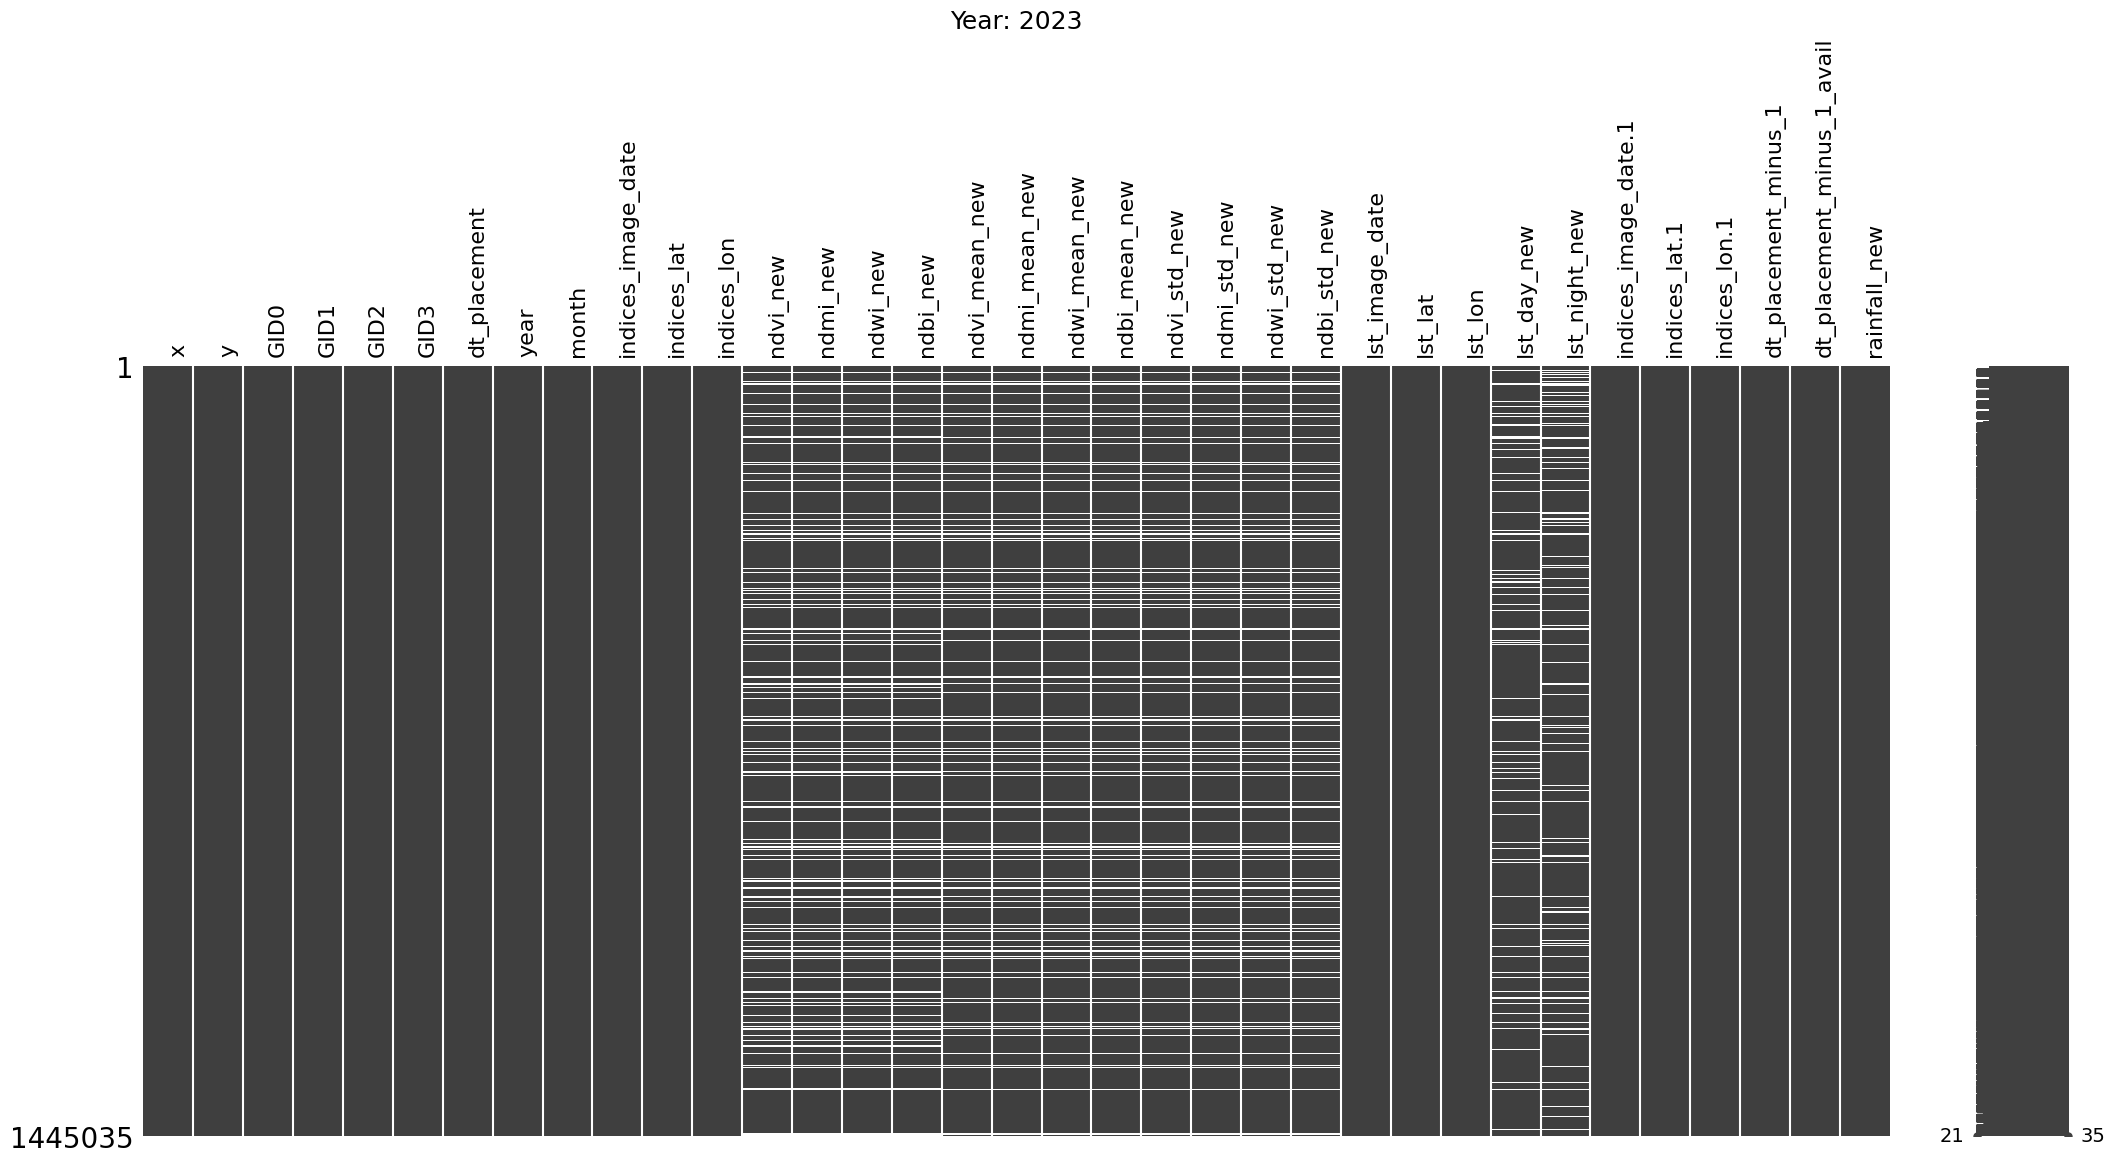

In [76]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df.year.iloc[0]}", fontsize=18)

In [77]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
12,ndvi_new,15.9427
13,ndmi_new,15.9425
14,ndwi_new,15.9423
15,ndbi_new,15.9425
16,ndvi_mean_new,12.7681
17,ndmi_mean_new,12.7695
18,ndwi_mean_new,12.7678
19,ndbi_mean_new,12.7795
20,ndvi_std_new,12.7681
21,ndmi_std_new,12.7695


In [78]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)
df = df.rename(columns=lambda x: re.sub('_new', '', x))

In [79]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
10,ndvi,15.9427
11,ndmi,15.9425
12,ndwi,15.9423
13,ndbi,15.9425
14,ndvi_mean,12.7681
15,ndmi_mean,12.7695
16,ndwi_mean,12.7678
17,ndbi_mean,12.7795
18,ndvi_std,12.7681
19,ndmi_std,12.7695


In [80]:
df2 = df.copy()

In [81]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

In [82]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
10,ndvi,15.9427
11,ndmi,15.9425
12,ndwi,15.9423
13,ndbi,15.9425
14,ndvi_mean,12.7681
15,ndmi_mean,12.7695
16,ndwi_mean,12.7678
17,ndbi_mean,12.7795
18,ndvi_std,12.7681
19,ndmi_std,12.7695


In [83]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [84]:
df2.reset_index(drop=True, inplace=True)

In [85]:
df2

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-01,2023,1,0.229248,-0.148433,-0.308036,0.148433,0.251176,-0.135636,-0.307917,0.135636,0.021703,0.022568,0.008868,0.022568,15143.0,NaN,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-02,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,NaN,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-03,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14538.0,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-04,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14517.0,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-05,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15292.0,14517.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445030,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-27,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,14885.0,14489.0,0.0
1445031,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-28,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,15184.0,14489.0,0.0
1445032,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-29,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,15093.0,14489.0,0.0
1445033,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-30,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,15243.0,14403.0,0.0


Text(0.5, 1.0, 'Year: 2023')

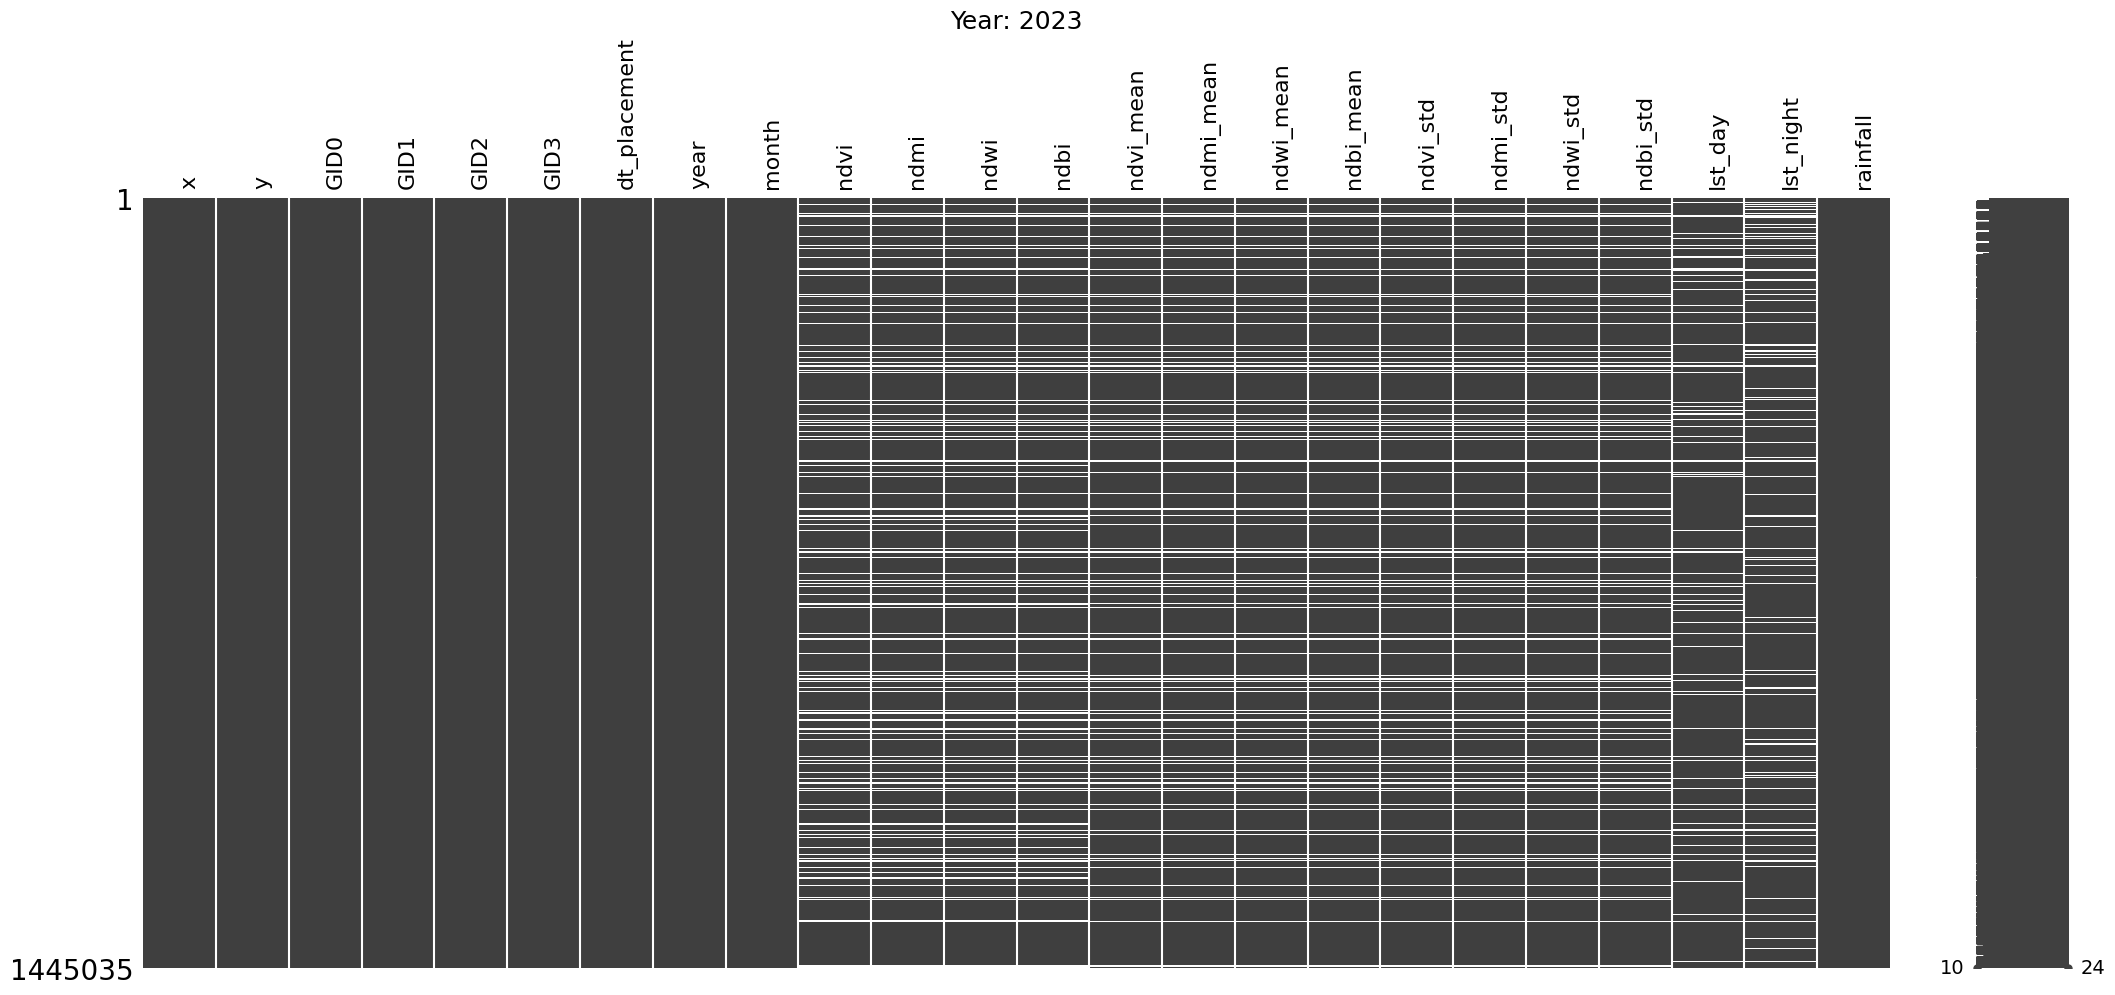

In [86]:
msno.matrix(df2, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df2.year.iloc[0]}", fontsize=18)

In [87]:
#df2.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding='utf-8')

In [88]:
df2.to_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_{YEAR}_filled_cleaned.csv', encoding='utf-8')

In [89]:
df2

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-01,2023,1,0.229248,-0.148433,-0.308036,0.148433,0.251176,-0.135636,-0.307917,0.135636,0.021703,0.022568,0.008868,0.022568,15143.0,NaN,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-02,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,NaN,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-03,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14538.0,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-04,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15261.0,14517.0,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2023-01-05,2023,1,0.313326,-0.039240,-0.384538,0.039240,0.302858,-0.049309,-0.381563,0.049309,0.029340,0.027244,0.017747,0.027244,15292.0,14517.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445030,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-27,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,14885.0,14489.0,0.0
1445031,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-28,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,15184.0,14489.0,0.0
1445032,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-29,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,15093.0,14489.0,0.0
1445033,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2023-12-30,2023,12,0.239676,-0.046601,-0.231595,0.046601,0.252889,-0.032052,-0.232288,0.032052,0.058311,0.051417,0.037018,0.051417,15243.0,14403.0,0.0
